In [1]:
import os
import json
import re
import pandas as pd
import shutup
shutup.please()
pd.options.display.max_columns = None

In [2]:
def extract_json(response: str):
    """Extract JSON content from a formatted string."""
    match = re.search(r"```json\s*(.*?)\s*```", response, re.DOTALL)
    if match:
        json_str = match.group(1)
    else:
        json_str = response.strip('```json').strip('```')
    
    try:
        return json.loads(json_str)
    except json.JSONDecodeError as e:
        print(f"Chyba při dekódování JSON: {e}")
        return None

In [3]:
def process_txt_files(folder_path, prefix):
    """Zpracuje všechny txt soubory začínající prefixem (např. 'bank_part') ve složce a vrátí Pandas DataFrame."""
    all_data = []
    
    # Get files with prefix and end with .txt
    files = [f for f in os.listdir(folder_path) if f.startswith(prefix) and f.endswith(".txt")]
    
    # Order by number
    files.sort(key=lambda x: int(re.search(r'chunk(\d+)', x).group(1)))
    
    for filename in files:
        file_path = os.path.join(folder_path, filename)
        with open(file_path, "r", encoding="utf-8") as file:
            for line in file:
                try:
                    json_obj = json.loads(line.strip())
                    content_str = json_obj.get("response", {}).get("body", {}).get("choices", [{}])[0].get("message", {}).get("content", "")
                    extracted_json = extract_json(content_str)
                    
                    if extracted_json:
                        row = {"id": json_obj["id"], "custom_id": json_obj["custom_id"]}
                        for feature in extracted_json.get("features", []):
                            row[feature["feature_name"]] = feature["answer"]
                        
                        all_data.append(row)
                except json.JSONDecodeError:
                    print(f"Chyba dekódování JSON v souboru {filename}")

    df = pd.DataFrame(all_data)
    return df

In [4]:
# Použití skriptu
folder_path = "../../data/outputs/m17"
df = process_txt_files(folder_path, "m17")

# Zobrazení výsledného dataframe
df

,id,custom_id,Research Discipline,Article Type,Research Impact,Methodology Complexity,Data Type,Sample Size,Funding Source,Collaboration Level,Publication Venue,Citation Count,Research Novelty,Interdisciplinary Nature,Research Focus,Geographical Context,Ethical Considerations,Technological Integration,Statistical Analysis,Language Complexity,Theoretical Framework,Data Availability
0,batch_req_67d58d2fa5988190b736ae4dc7e1b389,0,History,Theoretical Paper,Moderate,Complex,Qualitative,Medium,Other,Single Author,Journal,Medium,Incremental,Yes,Theoretical,National,Yes,Low,None,Complex,Well-defined,Restricted
1,batch_req_67d58d2fd6f08190b09c2ead30dde31c,1,Biology,Original Research,High,Complex,Quantitative,Medium,Other,Small Team,Journal,Medium,Innovative,Yes,Experimental,International,Yes,High,Inferential,Complex,Well-defined,Restricted
2,batch_req_67d58d2ffcbc8190b6f20a1d97d0b613,2,Physics,Original Research,High,Complex,Quantitative,Medium,Other,Small Team,Journal,Medium,Innovative,No,Theoretical,International,No,High,Inferential,Complex,Well-defined,Restricted
3,batch_req_67d58d301fa48190ac92391cadc4e64d,3,Other,Methodological Paper,Moderate,Complex,Quantitative,Medium,Other,Small Team,Book Chapter,Low,Incremental,Yes,Applied,International,No,High,Inferential,Complex,Well-defined,Open
4,batch_req_67d58d3046708190b2827845cf53342a,4,Biology,Original Research,High,Complex,Quantitative,Large,Other,Large Consortium,Journal,Medium,Innovative,Yes,Theoretical,International,No,Medium,Inferential,Complex,Well-defined,Open
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,batch_req_67d5b63512588190bc2c5eb671ab467d,1995,Physics,Original Research,High,Complex,Quantitative,Small,Other,Small Team,Journal,Medium,Innovative,No,Experimental,International,No,High,None,Complex,Well-defined,Restricted
1996,batch_req_67d5b6352de881908d07a67e9d65d3f6,1996,Engineering,Original Research,High,Complex,Quantitative,Medium,Other,Small Team,Journal,Medium,Innovative,Yes,Applied,International,No,High,Inferential,Complex,Well-defined,Restricted
1997,batch_req_67d5b63543c4819086ad9ac551eb13d1,1997,Other,Other,Moderate,Simple,Qualitative,Small,Other,Single Author,Other,Low,Incremental,Yes,Applied,International,No,Low,None,Simple,Absent,Not Available
1998,batch_req_67d5b63559c481908e2c7a7b7ce59e7f,1998,Physics,Methodological Paper,Moderate,Complex,Quantitative,Medium,Other,Small Team,Journal,Medium,Innovative,No,Applied,International,No,High,None,Moderate,Absent,Restricted


# Merge with target

In [5]:
df['label'] = pd.read_csv("../../data/outputs/m17+/m17_final.csv")['evaluation']

In [6]:
df

,id,custom_id,Research Discipline,Article Type,Research Impact,Methodology Complexity,Data Type,Sample Size,Funding Source,Collaboration Level,Publication Venue,Citation Count,Research Novelty,Interdisciplinary Nature,Research Focus,Geographical Context,Ethical Considerations,Technological Integration,Statistical Analysis,Language Complexity,Theoretical Framework,Data Availability,label
0,batch_req_67d58d2fa5988190b736ae4dc7e1b389,0,History,Theoretical Paper,Moderate,Complex,Qualitative,Medium,Other,Single Author,Journal,Medium,Incremental,Yes,Theoretical,National,Yes,Low,None,Complex,Well-defined,Restricted,1
1,batch_req_67d58d2fd6f08190b09c2ead30dde31c,1,Biology,Original Research,High,Complex,Quantitative,Medium,Other,Small Team,Journal,Medium,Innovative,Yes,Experimental,International,Yes,High,Inferential,Complex,Well-defined,Restricted,1
2,batch_req_67d58d2ffcbc8190b6f20a1d97d0b613,2,Physics,Original Research,High,Complex,Quantitative,Medium,Other,Small Team,Journal,Medium,Innovative,No,Theoretical,International,No,High,Inferential,Complex,Well-defined,Restricted,1
3,batch_req_67d58d301fa48190ac92391cadc4e64d,3,Other,Methodological Paper,Moderate,Complex,Quantitative,Medium,Other,Small Team,Book Chapter,Low,Incremental,Yes,Applied,International,No,High,Inferential,Complex,Well-defined,Open,1
4,batch_req_67d58d3046708190b2827845cf53342a,4,Biology,Original Research,High,Complex,Quantitative,Large,Other,Large Consortium,Journal,Medium,Innovative,Yes,Theoretical,International,No,Medium,Inferential,Complex,Well-defined,Open,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,batch_req_67d5b63512588190bc2c5eb671ab467d,1995,Physics,Original Research,High,Complex,Quantitative,Small,Other,Small Team,Journal,Medium,Innovative,No,Experimental,International,No,High,None,Complex,Well-defined,Restricted,5
1996,batch_req_67d5b6352de881908d07a67e9d65d3f6,1996,Engineering,Original Research,High,Complex,Quantitative,Medium,Other,Small Team,Journal,Medium,Innovative,Yes,Applied,International,No,High,Inferential,Complex,Well-defined,Restricted,5
1997,batch_req_67d5b63543c4819086ad9ac551eb13d1,1997,Other,Other,Moderate,Simple,Qualitative,Small,Other,Single Author,Other,Low,Incremental,Yes,Applied,International,No,Low,None,Simple,Absent,Not Available,5
1998,batch_req_67d5b63559c481908e2c7a7b7ce59e7f,1998,Physics,Methodological Paper,Moderate,Complex,Quantitative,Medium,Other,Small Team,Journal,Medium,Innovative,No,Applied,International,No,High,None,Moderate,Absent,Restricted,5


In [7]:
df = df.drop(columns=["id", "custom_id"])
data = pd.get_dummies( 
        df, sparse=False, prefix_sep='_'
    )

In [8]:
data

,label,Research Discipline_Biology,Research Discipline_Chemistry,Research Discipline_Computer Science,Research Discipline_Economics,Research Discipline_Education,Research Discipline_Engineering,Research Discipline_Environmental Science,Research Discipline_History,Research Discipline_Law,Research Discipline_Linguistics,Research Discipline_Literature,Research Discipline_Mathematics,Research Discipline_Medicine,Research Discipline_Other,Research Discipline_Philosophy,Research Discipline_Physics,Research Discipline_Psychology,Research Discipline_Social Sciences,Article Type_Case Study,Article Type_Commentary,Article Type_Conference,Article Type_Methodological Paper,Article Type_Original Research,Article Type_Other,Article Type_Review,Article Type_Theoretical Paper,Research Impact_High,Research Impact_Low,Research Impact_Moderate,Methodology Complexity_Complex,Methodology Complexity_Moderate,Methodology Complexity_Simple,Data Type_Mixed Methods,Data Type_Other,Data Type_Qualitative,Data Type_Quantitative,Sample Size_Large,Sample Size_Medium,Sample Size_N/A,Sample Size_Not Applicable,Sample Size_Not Available,Sample Size_Other,Sample Size_Small,Funding Source_Government,Funding Source_N/A,Funding Source_Other,Funding Source_Private,Funding Source_Self-funded,Collaboration Level_Large Consortium,Collaboration Level_Single Author,Collaboration Level_Small Team,Publication Venue_Book Chapter,Publication Venue_Conference,Publication Venue_Journal,Publication Venue_Other,Citation Count_High,Citation Count_Low,Citation Count_Medium,Citation Count_N/A,Citation Count_Not Applicable,Research Novelty_Groundbreaking,Research Novelty_Incremental,Research Novelty_Innovative,Interdisciplinary Nature_No,Interdisciplinary Nature_Yes,Research Focus_Applied,Research Focus_Experimental,Research Focus_Theoretical,Geographical Context_International,Geographical Context_Local,Geographical Context_National,Geographical Context_Not Applicable,Ethical Considerations_No,Ethical Considerations_Yes,Technological Integration_High,Technological Integration_Low,Technological Integration_Medium,Statistical Analysis_Descriptive,Statistical Analysis_Inferential,Statistical Analysis_None,Language Complexity_Complex,Language Complexity_Moderate,Language Complexity_Simple,Theoretical Framework_Absent,Theoretical Framework_Emerging,Theoretical Framework_Well-defined,Data Availability_Not Available,Data Availability_Open,Data Availability_Restricted
0,1,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,True,False,False,False,True,False,False,False,True,False,False,True,False,False,True,False,False,True,False,False,True,False,True,False,False,False,True,True,False,False,False,False,True,False,False,True
1,1,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,True,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,True,False,False,False,True,False,False,False,False,True,False,True,False,True,False,True,False,False,False,False,True,True,False,False,False,True,False,True,False,False,False,False,True,False,False,True
2,1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True,False,False,True,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,True,False,False,False,True,False,False,False,False,True,True,False,False,False,True,True,False,False,False,True,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,Tr

In [10]:
# 1) Libraries
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# 2) Příprava feature matic X a cílové proměnné y
X = data.drop(columns=["label"])
y = data["label"]
#categorical_columns = X.select_dtypes(include=["object"]).columns
#X = df.drop(columns=categorical_columns)

# 3) Rozdělení na trénovací a testovací sadu
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=y)  # stratify, pokud je to klasifikace s nerovnoměrnými třídami

# ----------------------------------------------------------------
# 4) Definice modelu RandomForestClassifier
model = RandomForestClassifier(random_state=42, class_weight='balanced')

# 5) Nastavení rozsahu parametrů pro RandomizedSearchCV
param_grid = {
    "n_estimators": [50, 100, 200],       # Počet stromů v lese
    "max_depth": [3, 5, 10, None],        # Maximální hloubka stromu
    "min_samples_split": [2, 5, 10],      # Minimální počet vzorků pro split
    "min_samples_leaf": [1, 2, 5],        # Minimální počet vzorků v listu
}

# 6) Konfigurace RandomizedSearchCV (n_iter a cv lze upravit dle potřeby)
random_search = GridSearchCV(
    model,
    param_grid=param_grid,
    cv=5,                  # 5-fold cross-validace
    scoring="accuracy",    # metrika, dle které se bude model porovnávat
    n_jobs=-1,             # využití všech CPU jader pro rychlejší výpočet
    verbose=1
)

# 7) Trénink modelu s vyhledáváním nejlepších hyperparametrů
random_search.fit(X_train, y_train)

# 8) Vypsání nejlepších parametrů a skóre
print("Nejlepší parametry:", random_search.best_params_)
print("Nejlepší skóre na trénovací cross-validaci:", random_search.best_score_)

# 9) Ověření na testovací sadě
best_model = random_search.best_estimator_  # získáme nejlepší nalezený model
y_pred = best_model.predict(X_test)

# 10) Vyhodnocení
print("Přesnost na testu:", accuracy_score(y_test, y_pred))
print("Classification report na testu:")
print(classification_report(y_test, y_pred))

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Nejlepší parametry: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 50}
Nejlepší skóre na trénovací cross-validaci: 0.365
Přesnost na testu: 0.36
Classification report na testu:
              precision    recall  f1-score   support

           1       0.39      0.65      0.49        80
           2       0.38      0.23      0.28        80
           3       0.23      0.07      0.11        80
           4       0.29      0.47      0.36        80
           5       0.48      0.38      0.42        80

    accuracy                           0.36       400
   macro avg       0.35      0.36      0.33       400
weighted avg       0.35      0.36      0.33       400



In [12]:
print(classification_report(y_test, y_pred, digits=3))
from sklearn.metrics import mean_absolute_error
print(f"MAE: {mean_absolute_error(y_test, y_pred)}")

              precision    recall  f1-score   support

           1      0.391     0.650     0.488        80
           2      0.383     0.225     0.283        80
           3      0.231     0.075     0.113        80
           4      0.290     0.475     0.360        80
           5      0.476     0.375     0.420        80

    accuracy                          0.360       400
   macro avg      0.354     0.360     0.333       400
weighted avg      0.354     0.360     0.333       400

MAE: 1.165


In [ ]:
import shap
# Plot SHAP summary plot
explainer = shap.Explainer(best_model.predict, X_train)
shap_values = explainer.shap_values(X_train)

In [ ]:
import matplotlib.pyplot as plt
import shap

# Plot SHAP summary plot
explainer = shap.Explainer(best_model.predict, X_train)
shap_values = explainer.shap_values(X_test)

# Create the plot but don't display it yet
shap.summary_plot(shap_values, X_test, show=False, color=plt.get_cmap('coolwarm'))

# Add gray grid lines
plt.grid(True, linestyle='-', alpha=0.3, color='grey')
# Save and display
plt.savefig(f"shap_m17_gpt.pdf", format="pdf", bbox_inches="tight")

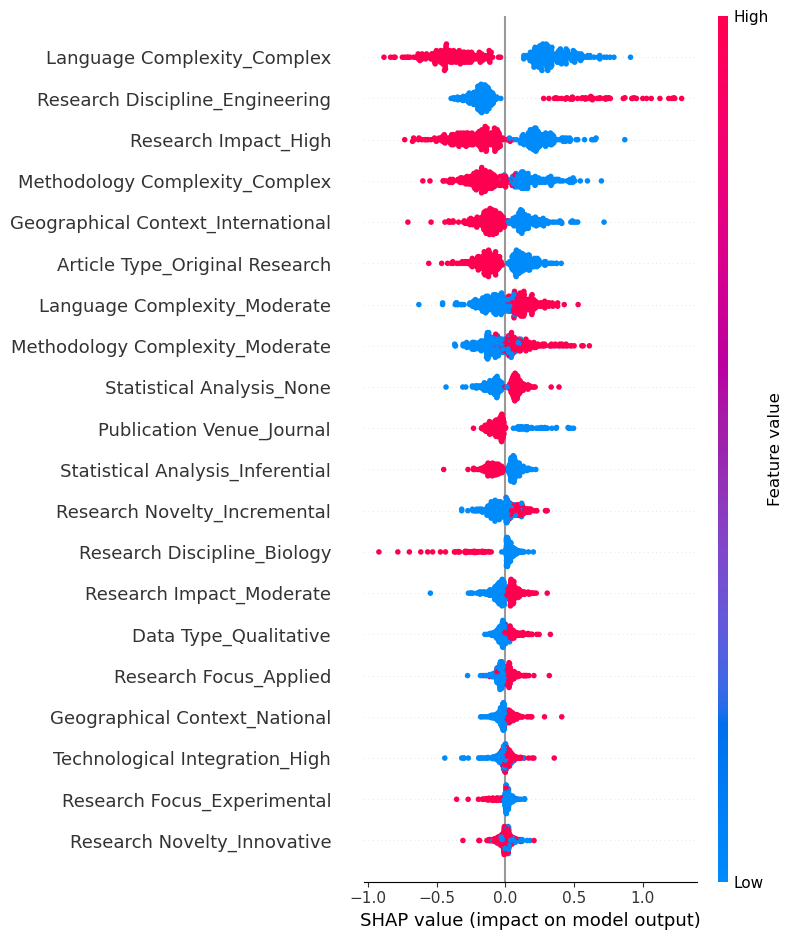

In [82]:
shap.summary_plot(shap_values, X_test, show=False, max_display=20)

# Add gray grid lines
# Save and display
plt.savefig(f"shap_m17_gpt.pdf", format="pdf", bbox_inches="tight", facecolor='white')
plt.show()